# Outliers

**Los outliers son valores extremos que se desvían significativamente de la tendencia general de un conjunto de datos**.
Estos puntos son atípicos y se encuentran alejados de la mayoría de las observaciones. Su presencia puede afectar drásticamente los resultados de un análisis y, si no se manejan adecuadamente, **pueden conducir a conclusiones erróneas**.

## Descifrando la importancia de los outliers en el análisis de datos

Los outliers pueden surgir por diversas razones, desde errores de medición hasta eventos raros o excepcionales. Su detección y gestión adecuadas son fundamentales para garantizar la precisión y confiabilidad de tus análisis de datos. A continuación, te presentamos algunas razones clave por las cuales los outliers son importantes:

### **1. Influencia en las métricas estadísticas**

Los outliers pueden sesgar significativamente las métricas estadísticas, como la media y la desviación estándar.

Si no se abordan, **pueden llevar a estimaciones inexactas y poco representativas de la población en estudio**. Aprender a identificarlos y tratarlos adecuadamente es vital para obtener resultados más precisos y realistas.

### **2. Impacto en la toma de decisiones**

En muchos escenarios, **las decisiones se basan en análisis de datos**.
Si los outliers no se tienen en cuenta, las decisiones pueden ser subóptimas o incluso desastrosas. Identificar estos valores atípicos te ayudará a tomar **decisiones más informadas y efectivas**.

### **3. Identificación de patrones y tendencias**

Los outliers también pueden revelar información valiosa sobre patrones y tendencias ocultas en los datos. Al analizarlos, **puedes descubrir aspectos únicos y excepcionales de tus datos** que merecen una consideración especial.

### **4. Detección de anomalías y fraudes**

En diversos campos, como el **análisis financiero y la detección de fraudes**, los outliers pueden ser señales de advertencia de **comportamientos inusuales o actividades sospechosas**. Detectarlos a tiempo puede prevenir situaciones potencialmente dañinas.

---
Para utilizar este código es necesario subir este archivo `ipynb` a la carpeta Colab Notebooks de Google Drive y abrir el archivo desde el navegador.

Emplazar el archivo de datos `Ejemplo_outliers.csv` en la carpeta sample_data (accesible en el desplegable de la izquierda de Google Colab, tras pulsar el icono de la carpeta)

También se puede ejecutar en local con un entorno python y la aplicación Jupyter Notebook.

## Apertura del csv de ejemplo

In [62]:
import pandas as pd
import numpy as np
data = pd.read_csv(r"C:\americo\ia_dema\11_Outliers\01_Ejercicio\trainmod.csv")

## Previsualización de los datos

In [39]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Crisis,Reforma
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,2,2008,WD,Normal,208500,SI,5
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,5,2007,WD,Normal,181500,NO,31
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,9,2008,WD,Normal,223500,SI,6
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,2,2006,WD,Abnorml,140000,NO,36
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,12,2008,WD,Normal,250000,SI,8


In [40]:
data.head(n=10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Crisis,Reforma
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,2,2008,WD,Normal,208500,SI,5
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,5,2007,WD,Normal,181500,NO,31
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,9,2008,WD,Normal,223500,SI,6
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,2,2006,WD,Abnorml,140000,NO,36
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,12,2008,WD,Normal,250000,SI,8
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,MnPrv,Shed,700,10,2009,WD,Normal,143000,SI,14
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,8,2007,WD,Normal,307000,NO,2
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,NaN,Shed,350,11,2009,WD,Normal,200000,SI,36
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,4,2008,WD,Abnorml,129900,SI,58
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,1,2008,WD,Normal,118000,SI,58


Datos estadísticos

In [41]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Reforma
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890,22.950000
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883,20.640653
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,-1.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,4.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,14.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,41.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000,60.000000


Comprobamos que no hay valores perdidos.

In [63]:
data.isnull()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Crisis,Reforma
0,False,False,False,False,False,False,True,False,False,False,...,True,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,True,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,True,True,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,...,True,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,...,True,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,False,False,False,False,False,False,True,False,False,False,...,True,True,False,False,False,False,False,False,False,False
1456,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1457,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1458,False,False,False,False,False,False,True,False,False,False,...,True,True,False,False,False,False,False,False,False,False


In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 83 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [66]:
# 1.1 – obtener lista de columnas con ≥1 NaN
missing_cols = data.columns[data.isnull().any()]

# 1.2 – quedar sólo con esas columnas
df_missing = data[missing_cols]

print("Columnas con faltantes:", list(missing_cols))
df_missing.head()


Columnas con faltantes: ['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']


,LotFrontage,Alley,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
0,65.0,NaN,BrkFace,196.0,Gd,TA,No,GLQ,Unf,SBrkr,NaN,Attchd,2003.0,RFn,TA,TA,NaN,NaN,NaN
1,80.0,NaN,NaN,0.0,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,1976.0,RFn,TA,TA,NaN,NaN,NaN
2,68.0,NaN,BrkFace,162.0,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,2001.0,RFn,TA,TA,NaN,NaN,NaN
3,60.0,NaN,NaN,0.0,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,1998.0,Unf,TA,TA,NaN,NaN,NaN
4,84.0,NaN,BrkFace,350.0,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,2000.0,RFn,TA,TA,NaN,NaN,NaN


In [54]:
# 1) Nombres de columnas numéricas
num_cols = data.select_dtypes(include='number').columns

# 2) Boolean mask de nulls solo en numéricas
num_nulls = data[num_cols].isnull()

# 3) Resumen de nulos por columna
report_num = (
    num_nulls.sum()
             .rename_axis('column')
             .reset_index(name='missing_count')
)
report_num['missing_pct'] = (100 * report_num['missing_count'] / len(data)).round(2)

# 4) Filtrar solo > 0
report_num = report_num[report_num['missing_count'] > 0]

print(report_num)


         column  missing_count  missing_pct
2   LotFrontage            259        17.74
8    MasVnrArea              8         0.55
25  GarageYrBlt             81         5.55


In [56]:
num_nulls.isnull().sum()

Id               0
MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
X1stFlrSF        0
X2ndFlrSF        0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageYrBlt      0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
X3SsnPorch       0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
Reforma          0
dtype: int64

In [68]:
df_num = data.select_dtypes(include=[np.number])
df_num

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Reforma
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,61,0,0,0,0,0,2,2008,208500,5
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,0,0,5,2007,181500,31
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,42,0,0,0,0,0,9,2008,223500,6
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,35,272,0,0,0,0,2,2006,140000,36
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,84,0,0,0,0,0,12,2008,250000,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,40,0,0,0,0,0,8,2007,175000,7
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,0,0,0,0,0,0,2,2010,210000,22
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,60,0,0,0,0,2500,5,2010,266500,4
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,0,112,0,0,0,0,4,2010,142125,14


In [70]:
df_num.isnull()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Reforma
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1457,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# Boxplot
El primer paso es realizar un "box-plot" para visualizar si existen outliers y como se distribuyen.

El boxplot proporciona una visión rápida y visualmente intuitiva de la distribución de los datos, permitiendo identificar la presencia de valores atípicos, la simetría o asimetría de los datos, la dispersión y la concentración de los datos alrededor de la mediana.

Las partes más *importantes* de un boxplot son:

1. **Caja (Box):** La caja en el centro del diagrama representa el rango intercuartílico (IQR, por sus siglas en inglés), que es la distancia entre el primer cuartil (Q1) y el tercer cuartil (Q3). La parte inferior de la caja indica Q1, y la parte superior indica Q3.

2. **Línea Mediana (Mediana o Medio de la caja):** La línea dentro de la caja representa la mediana del conjunto de datos. Esta línea divide la caja en dos partes iguales.

3. **Bigotes (Whiskers):** Los bigotes se extienden desde la caja hasta los valores extremos dentro de un rango específico. La longitud de los bigotes a menudo se define en términos de la dispersión de los datos o se calcula mediante alguna regla predefinida, como 1.5 veces el IQR.

4. **Valores Atípicos (Outliers):** Los valores atípicos, que son puntos individuales fuera de los bigotes, se indican en el diagrama y pueden ser importantes para identificar observaciones inusuales en el conjunto de datos.

5. **Línea de Máximos y Mínimos:** A veces, se incluyen líneas adicionales para indicar el valor mínimo y máximo dentro de un rango específico, excluyendo los valores atípicos.

Una de las opciones es analizar el boxplot de una variable individualmente

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html

In [9]:
import matplotlib.pyplot as plt

C:\Users\Dell\AppData\Local\Temp\ipykernel_784\2916653131.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_num_clean,


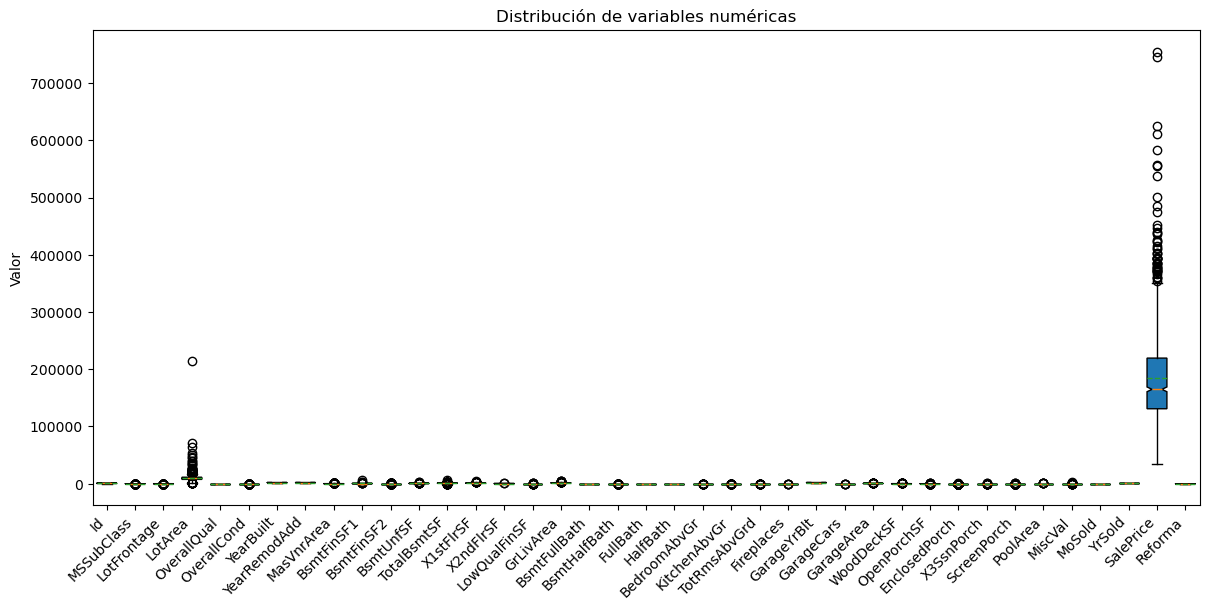

In [72]:
import matplotlib.pyplot as plt

# 1) Seleccionar sólo variables numéricas
num_cols = data.select_dtypes(include='number').columns
df_num   = data[num_cols]

# 2) (Opcional) quitar filas que tengan NaN en alguna de esas columnas
df_num_clean = df_num.dropna()

# 3) Dibujar el boxplot
plt.figure(figsize=(12,6))
plt.boxplot(df_num_clean,
            labels=df_num_clean.columns,
            showmeans=True,
            meanline=True,
            notch=True,
            widths=0.7,
            patch_artist=True)

# 4) Ajustar etiquetas
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylabel("Valor")
plt.title("Distribución de variables numéricas")
plt.show()


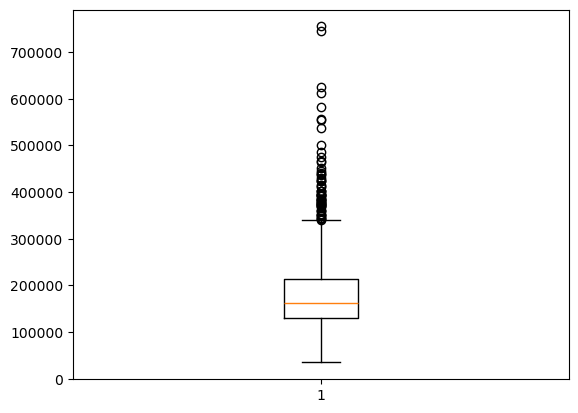

In [73]:
plt.boxplot(df_num["SalePrice"],);

C:\Users\Dell\AppData\Local\Temp\ipykernel_784\112518233.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data[["LotArea", "SalePrice"]],


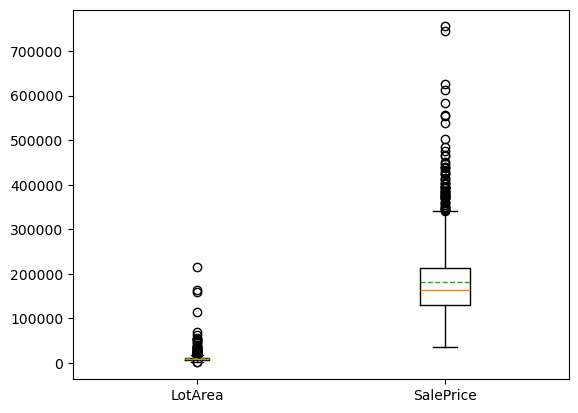

In [74]:
plt.boxplot(data[["LotArea", "SalePrice"]],
            notch=None,
            sym=None,
            vert=None, # False para horizontal
            whis=None, # Posición de los bigotes (por defecto 1.5)
            positions=None,
            widths=[0.1, 0.2], # Anchura como porción del total de la del gráfico
            patch_artist=None,
            bootstrap=None,
            usermedians=None,
            conf_intervals=None,
            meanline=True,
            showmeans=True,
            showcaps=None,
            showbox=None,
            showfliers=None,
            boxprops=None,
            labels=["LotArea", "SalePrice"], # Etiqueta del valor
            flierprops=None,
            medianprops=None,
            meanprops=None,
            capprops=None,
            whiskerprops=None,
            manage_ticks=True,
            autorange=False,
            zorder=None,
            capwidths=None,
);

Tambien podemos realizar un grafico de todas las variables a la vez.

C:\Users\Dell\AppData\Local\Temp\ipykernel_784\2916653131.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_num_clean,


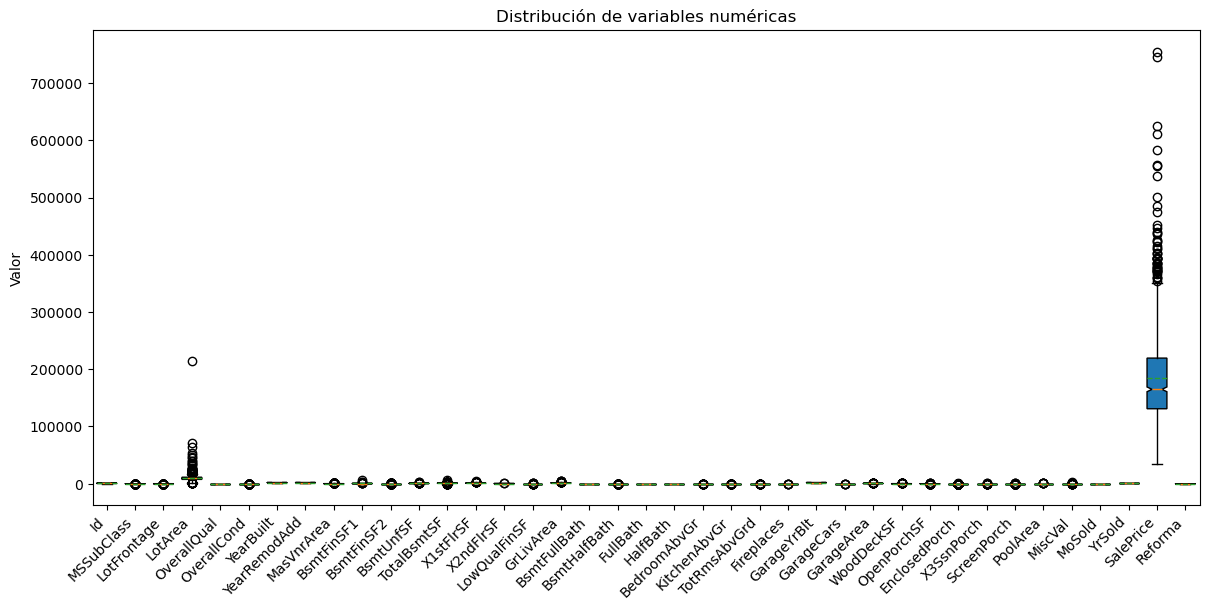

In [75]:
import matplotlib.pyplot as plt

# 1) Seleccionar sólo variables numéricas
num_cols = data.select_dtypes(include='number').columns
df_num   = data[num_cols]

# 2) (Opcional) quitar filas que tengan NaN en alguna de esas columnas
df_num_clean = df_num.dropna()

# 3) Dibujar el boxplot
plt.figure(figsize=(12,6))
plt.boxplot(df_num_clean,
            labels=df_num_clean.columns,
            showmeans=True,
            meanline=True,
            notch=True,
            widths=0.7,
            patch_artist=True)

# 4) Ajustar etiquetas
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.ylabel("Valor")
plt.title("Distribución de variables numéricas")
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_784\3046007908.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_num,


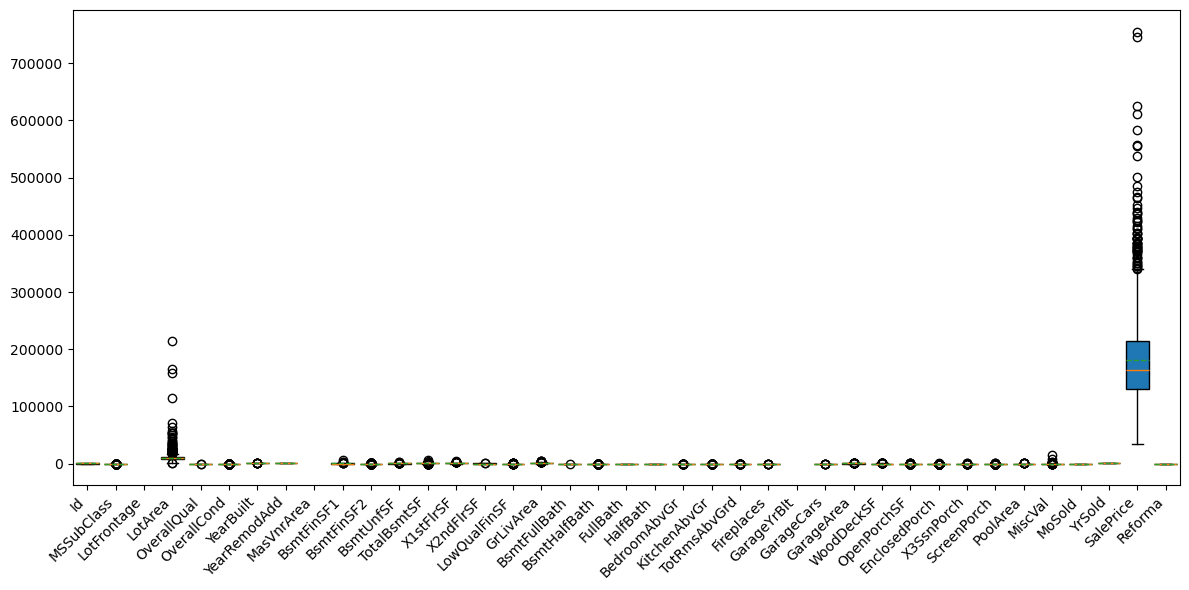

In [21]:
import matplotlib.pyplot as plt

# 1) Ampliar figura
plt.figure(figsize=(12, 6))

# 2) Dibujar boxplot
plt.boxplot(df_num,
            labels=df_num.columns,
            patch_artist=True,
            showmeans=True,
            meanline=True,
            widths=0.8,
            manage_ticks=True)

# 3) Rotar y alinear etiquetas
plt.xticks(rotation=45, ha='right')

# 4) Ajustar márgenes
plt.tight_layout()

plt.show()


In [19]:
df_num.columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'X1stFlrSF', 'X2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', 'X3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'Reforma'],
      dtype='object')

C:\Users\Dell\AppData\Local\Temp\ipykernel_784\151672205.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_num["SalePrice"],


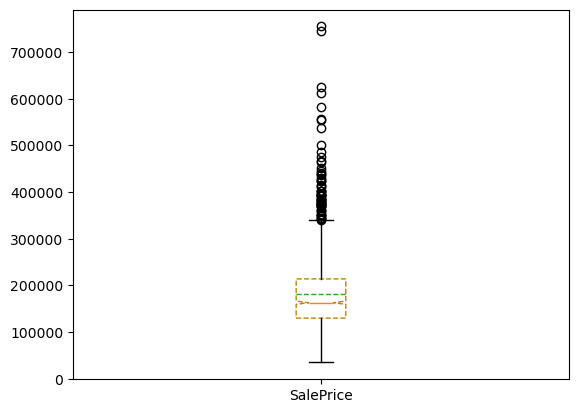

In [77]:
boxprops = dict(linestyle='--', linewidth=1, color='darkgoldenrod')
plt.boxplot(df_num["SalePrice"],
            notch=True,
            sym=None,
            vert=None, # False para horizontal
            whis=None, # Posición de los bigotes (por defecto 1.5)
            positions=None,
            widths=[0.1], # Anchura como porción del total de la del gráfico
            patch_artist=None,
            bootstrap=None,
            usermedians=None,
            conf_intervals=None,
            meanline=True,
            showmeans=True,
            showcaps=None,
            showbox=None,
            showfliers=None,
            boxprops=boxprops,  # Cambiar el color de relleno de la caja
            labels=["SalePrice"], # Etiqueta del valor
            flierprops=None,
            medianprops=None,
            meanprops=None,
            capprops=None,
            whiskerprops=None,
            manage_ticks=True,
            autorange=False,
            zorder=None,
            capwidths=None,
)
plt.show()

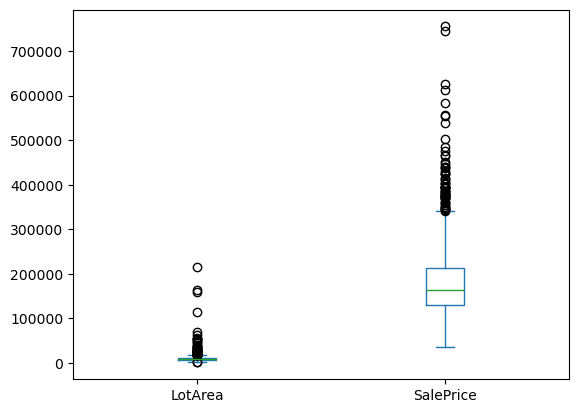

In [78]:
df_num[["LotArea", "SalePrice"]].plot(kind='box');

El analisis grafico nos permite ver que existen outliers en todas las variables incluidas en el modelo.<br>
Una vez que hemos constatado que existen outliers, la primera opcion es eliminar las filas que contienen outliers en alguna de las variables.

In [80]:
# ————————————————————————————————————————————————
# 4) Identificar variables 'numéricas' que en realidad son categoría
#    y repetir boxplot solo con las verdaderamente continuas
# ————————————————————————————————————————————————
# Definimos como "categóricas numéricas" aquellas con pocos niveles únicos
umbral_cat = 20
uniques = df_num.nunique()
cat_num = uniques[uniques <= umbral_cat].index.tolist()
cont_num = [c for c in df_num.columns if c not in cat_num]

print("Variables numéricas–categóricas:", cat_num)
print("Variables continuas:", cont_num)


Variables numéricas–categóricas: ['MSSubClass', 'OverallQual', 'OverallCond', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'X3SsnPorch', 'PoolArea', 'MoSold', 'YrSold']
Variables continuas: ['Id', 'LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'X1stFlrSF', 'X2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageYrBlt', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', 'MiscVal', 'SalePrice', 'Reforma']


C:\Users\Dell\AppData\Local\Temp\ipykernel_784\4146072983.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_num[cont_num].dropna().values,


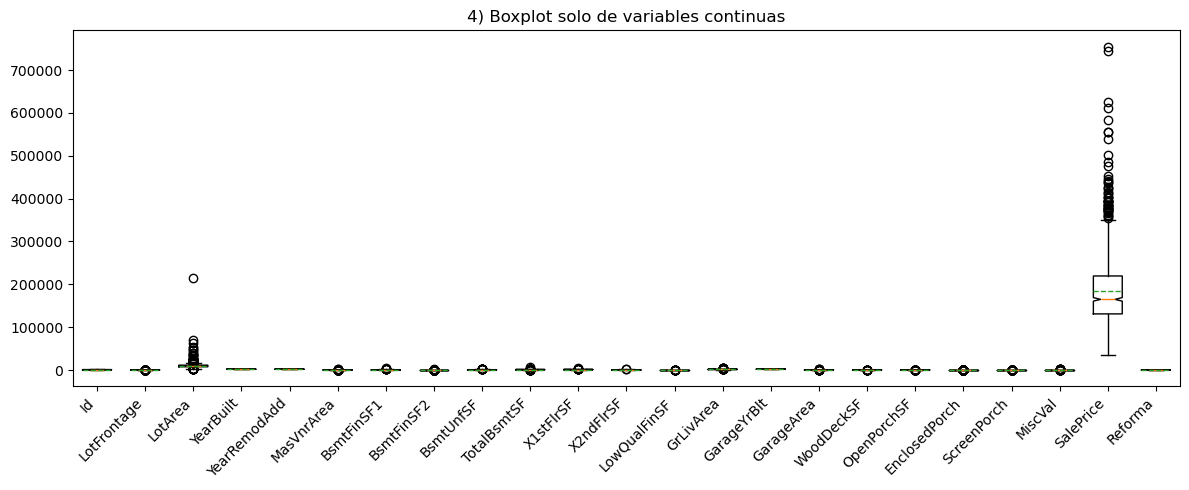

In [81]:

# boxplot solo de continuas
plt.figure(figsize=(12,5))
plt.boxplot(df_num[cont_num].dropna().values,
            labels=cont_num,
            showmeans=True, meanline=True, notch=True, widths=0.6)
plt.xticks(rotation=45, ha='right')
plt.title("4) Boxplot solo de variables continuas")
plt.tight_layout()
plt.show()

In [82]:
# ————————————————————————————————————————————————
# 5) Excluir variables distorsionantes (Id, YrSold, MoSold, Reforma…) 
#    y repetir el boxplot de continuas limpias
# ————————————————————————————————————————————————
drop_distors = ["Id","MoSold","YrSold","Reforma"]
vars_para_box = [c for c in cont_num if c not in drop_distors]


C:\Users\Dell\AppData\Local\Temp\ipykernel_784\4248137022.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_num[vars_para_box].dropna().values,


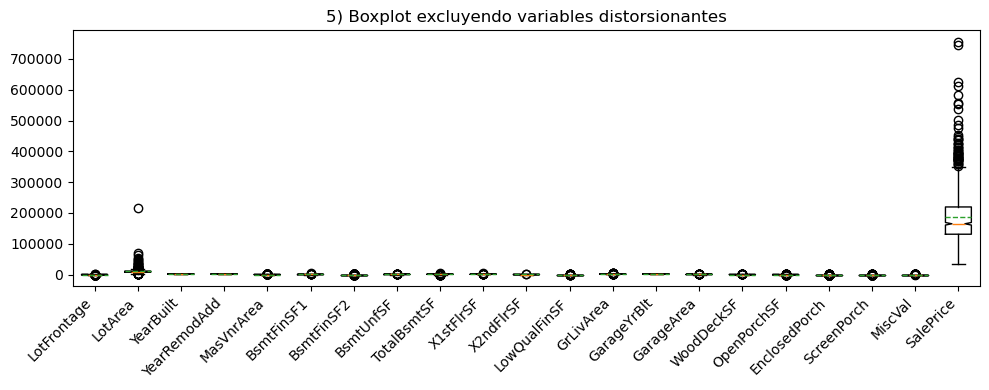

In [83]:

plt.figure(figsize=(10,4))
plt.boxplot(df_num[vars_para_box].dropna().values,
            labels=vars_para_box,
            showmeans=True, meanline=True, notch=True, widths=0.6)
plt.xticks(rotation=45, ha='right')
plt.title("5) Boxplot excluyendo variables distorsionantes")
plt.tight_layout()
plt.show()

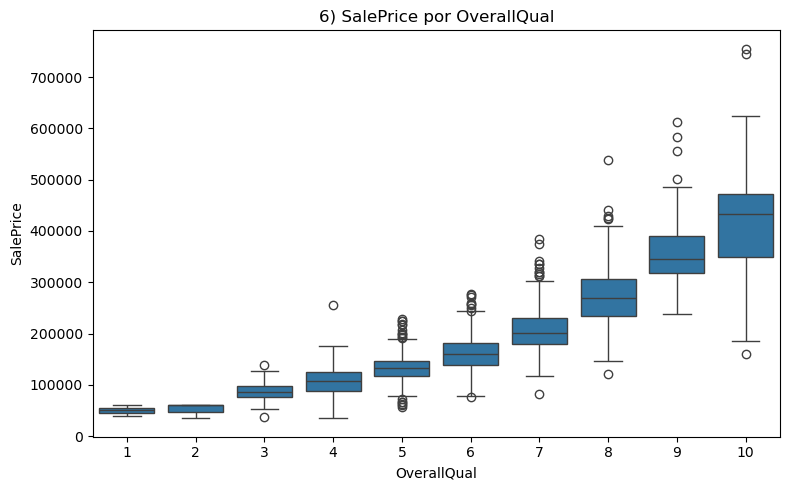

In [84]:
# ————————————————————————————————————————————————
# 6) Boxplot por grupo: p. ej. SalePrice vs OverallQual
#    y, si hace falta, descartamos niveles con pocas observaciones
# ————————————————————————————————————————————————

import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(x="OverallQual", y="SalePrice", data=data)
plt.title("6) SalePrice por OverallQual")
plt.tight_layout()
plt.show()

In [85]:
# ————————————————————————————————————————————————
# 7) Detectar outliers (por IQR) y anotar sus índices
# ————————————————————————————————————————————————
def detectar_outliers_iqr(s):
    q1, q3 = s.quantile([0.25,0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    return s[(s<lim_inf) | (s>lim_sup)].index

outliers = {}
for col in vars_para_box:
    idx = detectar_outliers_iqr(data[col].dropna())
    if len(idx)>0:
        outliers[col] = idx.tolist()
        print(f"... {col}: {len(idx)} outliers (e.g. indices {idx[:5]})")

# Unimos todos los índices que aparecen en cualquier variable
idx_out_all = sorted(set(sum(outliers.values(), [])))
print(f"Total filas que contienen outliers en alguna variable: {len(idx_out_all)}")

... LotFrontage: 88 outliers (e.g. indices Index([36, 41, 56, 75, 85], dtype='int64'))
... LotArea: 69 outliers (e.g. indices Index([53, 66, 113, 120, 159], dtype='int64'))
... YearBuilt: 7 outliers (e.g. indices Index([304, 630, 747, 991, 1132], dtype='int64'))
... MasVnrArea: 96 outliers (e.g. indices Index([25, 37, 56, 58, 64], dtype='int64'))
... BsmtFinSF1: 7 outliers (e.g. indices Index([53, 70, 178, 523, 898], dtype='int64'))
... BsmtFinSF2: 167 outliers (e.g. indices Index([7, 24, 26, 42, 43], dtype='int64'))
... BsmtUnfSF: 29 outliers (e.g. indices Index([22, 78, 137, 169, 224], dtype='int64'))
... TotalBsmtSF: 61 outliers (e.g. indices Index([17, 39, 70, 90, 102], dtype='int64'))
... X1stFlrSF: 20 outliers (e.g. indices Index([66, 70, 113, 175, 178], dtype='int64'))
... X2ndFlrSF: 2 outliers (e.g. indices Index([691, 1182], dtype='int64'))
... LowQualFinSF: 26 outliers (e.g. indices Index([51, 88, 125, 170, 185], dtype='int64'))
... GrLivArea: 31 outliers (e.g. indices Index(

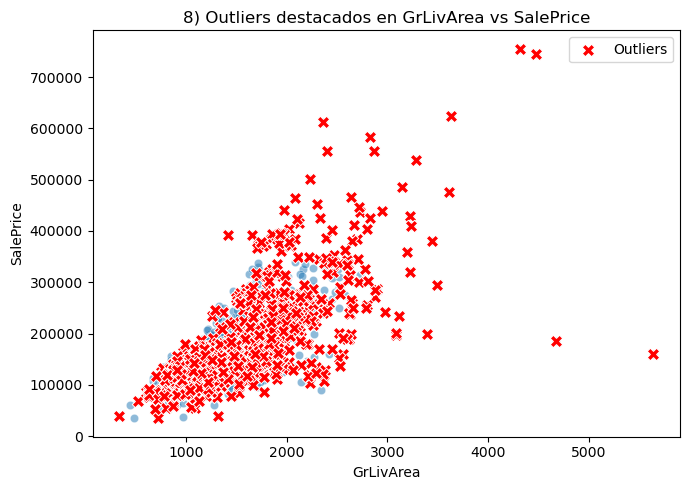

In [86]:
# ————————————————————————————————————————————————
# 8) Visualizar las observaciones con outliers de otra forma
#    Ejemplo: scatter SalePrice vs GrLivArea, marcando outliers
# ————————————————————————————————————————————————
plt.figure(figsize=(7,5))
sns.scatterplot(x="GrLivArea", y="SalePrice", data=data, alpha=0.5)
sns.scatterplot(x=data.loc[idx_out_all,"GrLivArea"],
                y=data.loc[idx_out_all,"SalePrice"],
                color="red", marker="X", s=80,
                label="Outliers")
plt.legend()
plt.title("8) Outliers destacados en GrLivArea vs SalePrice")
plt.tight_layout()

In [ ]:
# ————————————————————————————————————————————————
# 9) Transformar esos outliers en NA (solo en variables continuas,
#    excluyendo Id y SalePrice)
# ————————————————————————————————————————————————
df_proc = data.copy()
for col, idxs in outliers.items():
    df_proc.loc[idxs, col] = np.nan

# Verificación rápida
print("Valores nulos post-outliers:")
print(df_proc[vars_para_box].isnull().sum().loc[vars_para_box])

# Eliminación Z-score

In [24]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Reforma
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890,22.950000
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883,20.640653
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,-1.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,4.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,14.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,41.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000,60.000000


In [25]:
data.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Crisis,Reforma
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,2,2008,WD,Normal,208500,SI,5
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,5,2007,WD,Normal,181500,NO,31
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,9,2008,WD,Normal,223500,SI,6
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,2,2006,WD,Abnorml,140000,NO,36
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,12,2008,WD,Normal,250000,SI,8


In [26]:
!pip install scipy

In [27]:
import numpy as np
from scipy import stats

In [29]:
stats.zscore(df_num)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Reforma
0,-1.730865,0.073375,NaN,-0.207142,0.651479,-0.517200,1.050994,0.878668,NaN,0.575425,...,0.216503,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,0.138777,0.347273,-0.869941
1,-1.728492,-0.872563,NaN,-0.091886,-0.071836,2.179628,0.156734,-0.429577,NaN,1.171992,...,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-0.489110,-0.614439,0.007288,0.390141
2,-1.726120,0.073375,NaN,0.073480,0.651479,-0.517200,0.984752,0.830215,NaN,0.092907,...,-0.070361,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.990891,0.138777,0.536154,-0.821476
3,-1.723747,0.309859,NaN,-0.096897,0.651479,-0.517200,-1.863632,-0.720298,NaN,-0.499274,...,-0.176048,4.092524,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,-1.367655,-0.515281,0.632464
4,-1.721374,0.073375,NaN,0.375148,1.374795,-0.517200,0.951632,0.733308,NaN,0.463568,...,0.563760,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,2.100892,0.138777,0.869843,-0.724547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1.721374,0.073375,NaN,-0.260560,-0.071836,-0.517200,0.918511,0.733308,NaN,-0.973018,...,-0.100558,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.620891,-0.614439,-0.074560,-0.773012
1456,1.723747,-0.872563,NaN,0.266407,-0.071836,0.381743,0.222975,0.151865,NaN,0.759659,...,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,1.645210,0.366161,-0.046041
1457,1.726120,0.309859,NaN,-0.147810,0.651479,3.078570,-1.002492,1.024029,NaN,-0.369871,...,0.201405,-0.359325,-0.116339,-0.270208,-0.068692,4.953112,-0.489110,1.645210,1.077611,-0.918406
1458,1.728492,-0.872563,NaN,-0.080160,-0.795151,0.381743,-0.704406,0.539493,NaN,-0.865548,...,-0.704483,1.473789,-0.116339,-0.270208,-0.068692,-0.087688,-0.859110,1.645210,-0.488523,-0.433759


In [30]:
stats.zscore(df_num) >3

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Reforma
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1457,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [32]:
data = df_num.copy()

In [33]:
import numpy as np
from scipy import stats
data[(np.abs(stats.zscore(data)) > 3).any(axis=1)]

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Reforma
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,0,0,5,2007,181500,31
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,35,272,0,0,0,0,2,2006,140000,36
5,6,50,85.0,14115,5,5,1993,1995,0.0,732,...,30,0,320,0,0,700,10,2009,143000,14
7,8,60,NaN,10382,7,6,1973,1973,240.0,859,...,204,228,0,0,0,350,11,2009,200000,36
8,9,50,51.0,6120,7,5,1931,1950,0.0,0,...,0,205,0,0,0,0,4,2008,129900,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,1446,85,70.0,8400,6,5,1966,1966,0.0,187,...,0,252,0,0,0,0,5,2007,129000,41
1450,1451,90,60.0,9000,5,5,1974,1974,0.0,0,...,45,0,0,0,0,0,9,2009,136000,35
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,60,0,0,0,0,2500,5,2010,266500,4
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,0,112,0,0,0,0,4,2010,142125,14


In [34]:
dataSinOut = data[(np.abs(stats.zscore(data)) < 3).all(axis=1)]

Este código utiliza el criterio Z para identificar y eliminar outliers en un conjunto de datos.

1. `import numpy as np` y `from scipy import stats`: Importan las bibliotecas NumPy y SciPy. Estas bibliotecas proporcionan funcionalidades para manipulación de datos y operaciones estadísticas, respectivamente.

2. `dataSinOut = data[(np.abs(stats.zscore(data)) < 3).all(axis=1)]`:

   - `stats.zscore(data)`: Calcula los Z-scores para cada punto de datos en el conjunto de datos `data`. Un Z-score es una medida que indica la distancia desde la media al punto de datos medido en "número de veces la desviación típica".
   
   - `np.abs(...) < 3`: Compara cada Z-score calculado con el valor 3 en términos absolutos. Esto crea una matriz booleana donde `True` indica que el valor Z es menor que 3 y, por lo tanto, no se considera un outlier.
   
   - `.all(axis=1)`: Realiza una operación lógica "y" a lo largo del eje 1 (a lo largo de las filas) de la matriz booleana. Esto significa que todas las condiciones deben ser `True` a lo largo de una fila para que esa fila no sea considerada un outlier.

   - `data[(np.abs(stats.zscore(data)) < 3).all(axis=1)]`: Filtra el conjunto de datos original (`data`) para incluir solo las filas que cumplen con la condición de que todos los Z-scores en esa fila son menores que 3 en valor absoluto. Por lo tanto, se eliminan las filas que contienen outliers según el criterio Z.


In [35]:
# Visualización de las filas que han sido eliminadas
data[(np.abs(stats.zscore(data)) > 3).any(axis=1)]

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Reforma
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,0,0,5,2007,181500,31
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,35,272,0,0,0,0,2,2006,140000,36
5,6,50,85.0,14115,5,5,1993,1995,0.0,732,...,30,0,320,0,0,700,10,2009,143000,14
7,8,60,NaN,10382,7,6,1973,1973,240.0,859,...,204,228,0,0,0,350,11,2009,200000,36
8,9,50,51.0,6120,7,5,1931,1950,0.0,0,...,0,205,0,0,0,0,4,2008,129900,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,1446,85,70.0,8400,6,5,1966,1966,0.0,187,...,0,252,0,0,0,0,5,2007,129000,41
1450,1451,90,60.0,9000,5,5,1974,1974,0.0,0,...,45,0,0,0,0,0,9,2009,136000,35
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,60,0,0,0,0,2500,5,2010,266500,4
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,0,112,0,0,0,0,4,2010,142125,14


In [36]:
dataSinOut

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,X3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,Reforma


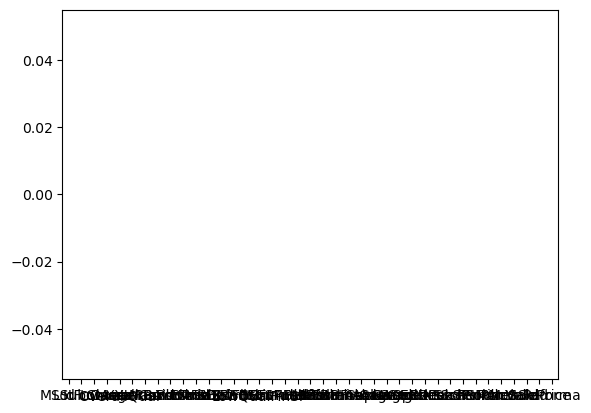

In [37]:
dataSinOut.plot(kind='box');

# Eliminación con cuantiles

Volvemos a cargar el dataset

In [25]:
data = pd.read_csv("/content/sample_data/Ejemplo_outliers.csv")

Otra forma de eliminar los datos en funcion del quantil es la siguiente.
En este caso habria que hacerlo para cada una de las variables.<br>
Este procedimiento puede ser interesante si estamos interesados en descartar algun tipo de evento concreto
que se halle focalizado en alguna de las variables.

In [26]:
data["G1"].quantile(0.15)

np.float64(-0.2308)

In [27]:
data["G1"].quantile(0.85)

np.float64(0.6571999999999997)

In [28]:
qB = data["G1"].quantile(0.15)
qA = data["G1"].quantile(0.85)
dataSinOut = data[(data["G1"] > qB) & (data["G1"] < qA)]

dataSinOut

,G1,G2,G3,G4,G5,G6,G7,G8,G9
0,0.175,0.188,-0.159,0.095,0.374,-0.238,-0.800,0.158,-0.211
1,0.102,0.075,0.141,0.180,0.138,-0.057,-0.075,0.072,0.072
2,0.607,0.711,0.879,0.765,0.592,0.187,0.431,0.345,0.187
4,0.504,0.644,0.845,0.681,0.502,0.151,0.404,0.296,0.260
5,0.570,0.729,0.879,0.624,0.588,0.204,0.435,-0.018,0.354
...,...,...,...,...,...,...,...,...,...
179,0.535,0.524,0.649,0.475,0.486,0.657,0.941,0.527,0.494
180,0.041,0.056,0.194,0.234,-0.003,-0.310,0.267,-0.449,-0.432
181,0.507,0.563,0.539,0.634,0.471,0.578,0.686,0.763,0.576
182,-0.033,-0.025,0.118,0.148,-0.076,-0.403,-0.345,0.084,-0.473


In [29]:
len(dataSinOut), len(data)

(128, 184)

Volvemos a realizar el grafico.
Solo se han eliminado los outliers de la primera variable.
Sin embargo observamos que han desaparecido los outliers para la mayoria de las observaciones.

In [31]:
qB = dataSinOut["G6"].quantile(0.15)
qA = dataSinOut["G6"].quantile(0.85)
dataSinOut=dataSinOut[(dataSinOut["G6"] > qB) & (data["G6"] < qA)]

dataSinOut

<ipython-input-31-ce750e1b2ba4>:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dataSinOut=dataSinOut[(dataSinOut["G6"] > qB) & (data["G6"] < qA)]


,G1,G2,G3,G4,G5,G6,G7,G8,G9
0,0.175,0.188,-0.159,0.095,0.374,-0.238,-0.800,0.158,-0.211
1,0.102,0.075,0.141,0.180,0.138,-0.057,-0.075,0.072,0.072
2,0.607,0.711,0.879,0.765,0.592,0.187,0.431,0.345,0.187
4,0.504,0.644,0.845,0.681,0.502,0.151,0.404,0.296,0.260
5,0.570,0.729,0.879,0.624,0.588,0.204,0.435,-0.018,0.354
...,...,...,...,...,...,...,...,...,...
160,0.331,0.233,0.788,0.350,1.051,0.068,1.122,0.897,0.630
164,0.474,0.486,0.606,0.666,0.468,-0.010,0.165,1.095,-0.012
174,0.007,-0.060,0.073,0.105,0.007,-0.071,-0.348,-0.060,0.105
175,0.299,0.564,0.342,0.297,0.444,0.233,0.052,0.645,-0.114


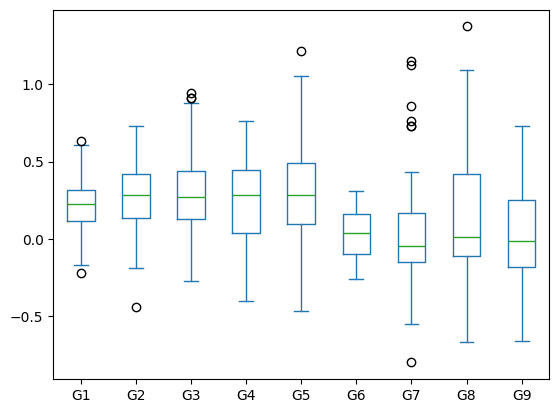

In [32]:
dataSinOut.plot(kind='box');

Esto nos lleva a plantearnos que los outliers se agrupan en las mismas observaciones.
A continuacion mostramos aquellas observaciones en las que se encuentran los outliers.
Para ello modificamos ligeramente el codigo anterior.

In [33]:
qB = data["G1"].quantile(0.15)
qA = data["G1"].quantile(0.85)
dataOut = data[(data["G1"] < qB) | (data["G1"] > qA)]
dataOut

,G1,G2,G3,G4,G5,G6,G7,G8,G9
3,0.774,0.823,0.619,0.370,0.725,0.439,-0.025,-0.259,0.496
6,0.885,0.932,0.878,0.662,0.839,0.917,0.593,0.252,0.801
8,1.396,1.461,1.342,1.122,1.394,1.408,0.924,0.638,1.375
17,-0.315,-0.148,-0.330,0.150,-0.266,0.382,-0.246,0.417,-0.428
20,-0.558,-0.705,-0.526,-0.412,-0.753,-0.998,-0.270,0.598,-1.416
22,-0.444,-0.315,-0.461,-0.278,0.283,0.068,1.185,-0.246,-0.097
25,-0.300,0.083,-0.266,-0.148,-0.148,0.744,-0.246,0.728,0.283
38,7.197,8.060,7.223,7.589,7.258,8.310,7.835,8.931,7.824
39,2.190,2.664,2.325,2.430,2.253,3.303,2.502,3.627,2.727
42,-0.338,-0.479,-0.366,-0.269,-0.366,-0.721,-0.495,-0.721,-0.543


En este caso observamos que tenemos muchos outliers.
Realmente estamos más interesados en saber qué ocurre con los valores verdaderamente extremos.
Por ello ajustamos más los porcentajes para seleccionar aquellos valores en los que estamos interesados.

In [ ]:
qB = data["G1"].quantile(0.01)
qA = data["G1"].quantile(0.99)
data_excluidos = data[(data["G1"] < qB) | (data["G1"] > qA)]
data_excluidos

,G1,G2,G3,G4,G5,G6,G7,G8,G9
38,7.197,8.060,7.223,7.589,7.258,8.310,7.835,8.931,7.824
39,2.190,2.664,2.325,2.430,2.253,3.303,2.502,3.627,2.727
65,-1.031,-0.493,-0.861,-0.846,-0.984,-0.097,-0.781,0.036,-0.677
102,-1.171,-1.186,-0.564,-1.186,-0.924,-1.095,-0.660,-1.203,-0.757


Podemos observar que la observacion 38 agrupa valores muy extremos y que realmente resultan muy anomalos.<br>
Una observacion asi puede distorsionar un modelo. Por ello seria adecuado estudiar dicha variable por separado y excluirla del modelo.

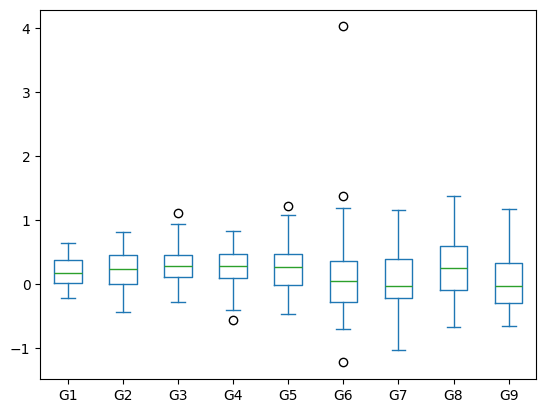

In [34]:
data_resultantes = data[~((data["G1"] < qB) | (data["G1"] > qA))]
data_resultantes.plot(kind='box');

Sin embargo en el grafico anterior observamos que en la variable "G6" sigue existiendo un outlier que no hemos recogido.<br>
De cara a entender bien nuestros datos es conveniente saber que ocurre con esa observacion.
Por ello repetimos el proceso.<br>

In [ ]:
qB6 = data["G6"].quantile(0.01)
qA6 = data["G6"].quantile(0.99)
data_excluidos6 = data[(data["G6"] < qB6) | (data["G6"] > qA6)]
data_excluidos6

,G1,G2,G3,G4,G5,G6,G7,G8,G9
38,7.197,8.060,7.223,7.589,7.258,8.310,7.835,8.931,7.824
56,-0.762,-0.686,-0.863,-0.826,-0.824,-1.252,-1.470,-1.283,-0.992
145,0.002,-0.083,0.300,-0.097,0.396,-1.225,0.331,0.368,0.150
154,-0.107,-0.093,0.065,0.114,-0.072,4.029,-0.055,-0.062,-0.454


En este analisis vemos que en la observacion que estamos tratando (la 154) el resto de las variables toman valores que podemos calificar como normales.

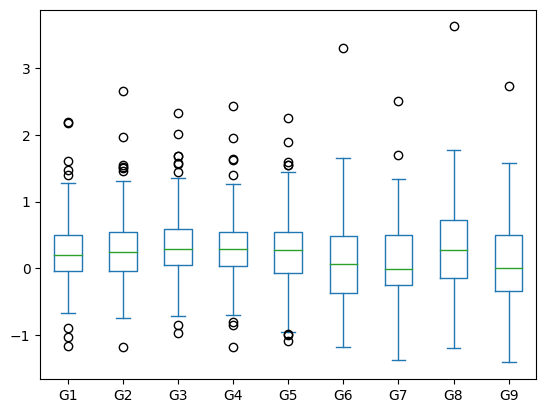

In [ ]:
data_resultantes6 = data[~((data["G6"] < qB6) | (data["G6"] > qA6))]
data_resultantes6.plot(kind='box');

Volvemos a cargar los datos.

In [35]:
data = pd.read_csv("/content/sample_data/Ejemplo_outliers.csv")

Tambien podemos utilizar la primera metodologia columna por columna.

In [36]:
from scipy import stats
data[(np.abs(stats.zscore(data["G1"])) < 3)]

,G1,G2,G3,G4,G5,G6,G7,G8,G9
0,0.175,0.188,-0.159,0.095,0.374,-0.238,-0.800,0.158,-0.211
1,0.102,0.075,0.141,0.180,0.138,-0.057,-0.075,0.072,0.072
2,0.607,0.711,0.879,0.765,0.592,0.187,0.431,0.345,0.187
3,0.774,0.823,0.619,0.370,0.725,0.439,-0.025,-0.259,0.496
4,0.504,0.644,0.845,0.681,0.502,0.151,0.404,0.296,0.260
...,...,...,...,...,...,...,...,...,...
179,0.535,0.524,0.649,0.475,0.486,0.657,0.941,0.527,0.494
180,0.041,0.056,0.194,0.234,-0.003,-0.310,0.267,-0.449,-0.432
181,0.507,0.563,0.539,0.634,0.471,0.578,0.686,0.763,0.576
182,-0.033,-0.025,0.118,0.148,-0.076,-0.403,-0.345,0.084,-0.473


En estos tres procedimientos hemos visto diferentes formas de eliminar los valores extremos.

Existen otras muchas ocasiones en las que estos valores juegan un papel clave para el modelo.

De hecho en algunos casos son mas importantes los valores extremos que los valores "normales".

En estas ocasiones nos interesa crear una nueva variable que nos marque si una determinada observacion es un outlier o no.

Ademas en estos casos nos puede interesar diferenciar si se trata de un outlier "por arriba" o "por abajo".

Volvemos a cargar los datos.

In [37]:
data = pd.read_csv("/content/sample_data/Ejemplo_outliers.csv")

Lo primero que tenemos que hacer es calcular los estadisticos basicos para la deteccion de outliers (media o mediana y desviacion tipica)

In [38]:
data.describe()

,G1,G2,G3,G4,G5,G6,G7,G8,G9
count,184.000000,184.000000,184.000000,184.000000,184.00000,184.000000,184.000000,184.000000,184.000000
mean,0.249245,0.293576,0.351696,0.316196,0.30250,0.143277,0.156185,0.304603,0.131821
std,0.720936,0.780485,0.727749,0.742577,0.73937,0.923092,0.822092,0.901041,0.819553
min,-1.171000,-1.186000,-0.975000,-1.186000,-1.09500,-1.252000,-1.470000,-1.283000,-1.416000
25%,-0.053000,-0.062000,0.047750,0.025000,-0.07100,-0.383500,-0.260250,-0.144250,-0.367000
50%,0.181000,0.235500,0.284000,0.288000,0.26600,0.068000,-0.015500,0.272000,0.009000
75%,0.491250,0.548000,0.588500,0.549750,0.54075,0.484000,0.501500,0.728000,0.496000
max,7.197000,8.060000,7.223000,7.589000,7.25800,8.310000,7.835000,8.931000,7.824000


Otra opcion en vez de eliminar la observacion es transformarlos NAs


# Guardado de las posiciones de los outliers

Vuelvo a cargar los datos.

In [44]:
data = pd.read_csv("/content/sample_data/Ejemplo_outliers.csv")

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Ésta es una forma de ver en cada variable en que observacion se encuentran los outliers.

Marca como outliers aquellas observaciones que difieran de la media mas de tres veces la desviacion tipica.

Creamos un DataFrame en el que guardamos, en un sólo registro los registros del DataFrame original que se califican como outliers

In [46]:
import numpy as np

def outliers_z_score(ys):
    threshold = 3

    mean_y = np.mean(ys)
    stdev_y = np.std(ys)
    z_scores = [(y - mean_y) / stdev_y for y in ys]
    return np.where(np.abs(z_scores) > threshold)

datos = data.apply(outliers_z_score)
datos

,G1,G2,G3,G4,G5,G6,G7,G8,G9
0,[38],"[38, 39]",[38],[38],[38],"[38, 39, 154]",[38],"[38, 39]","[38, 39]"


In [47]:
type(datos)

pandas.core.frame.DataFrame

Otra forma de ver en cada variable en que observacion se encuentran los outliers.
En este caso nos basamos en la desviacion desde la mediana.


In [48]:
import numpy as np

def outliers_modified_z_score(ys):
    threshold = 3.5

    median_y = np.median(ys)
    median_absolute_deviation_y = np.median([np.abs(y - median_y) for y in ys])
    modified_z_scores = [0.6745 * (y - median_y) / median_absolute_deviation_y
                         for y in ys]
    return np.where(np.abs(modified_z_scores) > threshold)

datos=data.apply(outliers_modified_z_score)
datos

,G1,G2,G3,G4,G5,G6,G7,G8,G9
0,"[38, 39, 110, 152]","[38, 39, 110]","[38, 39, 110, 120, 121]","[38, 39, 102, 110]","[38, 39]","[38, 39, 154]","[38, 39]","[38, 39]","[38, 39]"


Otra forma de ver en cada variable en que observacion se encuentran los outliers.

Se fundamenta en la diferencia para el percentil 25 y 75.


In [49]:
quartile_1, quartile_3 = np.percentile(data["G1"], [25, 75])
print(np.percentile(data["G1"], [25, 75]))

[-0.053    0.49125]


In [50]:
quartile_1, quartile_3

(np.float64(-0.053), np.float64(0.49124999999999996))

In [51]:
import numpy as np

def outliers_iqr(ys):
    quartile_1, quartile_3 = np.percentile(ys, [25, 75])
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    return np.where((ys > upper_bound) | (ys < lower_bound))

datos=data.apply(outliers_iqr)
datos

,G1,G2,G3,G4,G5,G6,G7,G8,G9
0,"[8, 38, 39, 59, 65, 102, 110, 112, 152]","[38, 39, 61, 102, 110, 112, 152]","[38, 39, 56, 59, 65, 110, 112, 117, 120, 121, ...","[38, 39, 54, 56, 65, 102, 110, 112, 117, 152]","[38, 39, 59, 64, 110, 120, 121, 152]","[38, 39, 154]","[38, 39, 56, 152]","[38, 39]","[38, 39]"


Para ello utilizamos una formula ya utilizada pero modificada, igual que antes.

Realizamos la comprobacion de antes

Mostramos la fila que nos interesa (un numero menos ya que se ha eliminado la fila 38)

In [52]:
from scipy import stats
import numpy as np
data1=data[(np.abs(stats.zscore(data)) < 3).all(axis=1)]

print(data1)
print("\nÚltimas 40 filas\n")
print(data1.tail(n=40))
print("\nFila154\n")
print(data1.iloc[153,:])

        G1     G2     G3     G4     G5     G6     G7     G8     G9
0    0.175  0.188 -0.159  0.095  0.374 -0.238 -0.800  0.158 -0.211
1    0.102  0.075  0.141  0.180  0.138 -0.057 -0.075  0.072  0.072
2    0.607  0.711  0.879  0.765  0.592  0.187  0.431  0.345  0.187
3    0.774  0.823  0.619  0.370  0.725  0.439 -0.025 -0.259  0.496
4    0.504  0.644  0.845  0.681  0.502  0.151  0.404  0.296  0.260
..     ...    ...    ...    ...    ...    ...    ...    ...    ...
179  0.535  0.524  0.649  0.475  0.486  0.657  0.941  0.527  0.494
180  0.041  0.056  0.194  0.234 -0.003 -0.310  0.267 -0.449 -0.432
181  0.507  0.563  0.539  0.634  0.471  0.578  0.686  0.763  0.576
182 -0.033 -0.025  0.118  0.148 -0.076 -0.403 -0.345  0.084 -0.473
183  0.470  0.520  0.526  0.553  0.650  0.920  0.466  0.608  0.550

[181 rows x 9 columns]

Últimas 40 filas

        G1     G2     G3     G4     G5     G6     G7     G8     G9
143  0.254  0.338  0.327  0.306  0.231  0.517  0.496  0.877  0.007
144  0.283  0.530  

# Sustitución de Outliers

Hasta ahora hamos visto como identificar los outliers de diferente maneras para eliminarlos, mediante diferentes metodos.

A continuacion mostramos como identificar los outliers y como sustituirlos.

Vuelvo a cargar los datos.

In [53]:
data = pd.read_csv("/content/sample_data/Ejemplo_outliers.csv")

### Usando la media

Mediante esta formula podemos sustituir los outliers por la media.

In [54]:
def replace(group):
    mean = group.mean()
    median = group.median()
    std = group.std()
    outliers = (group - mean).abs() > 3*std
    group[outliers] = median
    return group

datos=data.apply(replace)

data.head(n=40)

,G1,G2,G3,G4,G5,G6,G7,G8,G9
0,0.175,0.1880,-0.159,0.095,0.374,-0.238,-0.8000,0.158,-0.211
1,0.102,0.0750,0.141,0.180,0.138,-0.057,-0.0750,0.072,0.072
2,0.607,0.7110,0.879,0.765,0.592,0.187,0.4310,0.345,0.187
3,0.774,0.8230,0.619,0.370,0.725,0.439,-0.0250,-0.259,0.496
4,0.504,0.6440,0.845,0.681,0.502,0.151,0.4040,0.296,0.260
5,0.570,0.7290,0.879,0.624,0.588,0.204,0.4350,-0.018,0.354
6,0.885,0.9320,0.878,0.662,0.839,0.917,0.5930,0.252,0.801
7,-0.029,0.0650,0.258,0.078,-0.053,-0.456,-0.1530,-0.356,-0.379
8,1.396,1.4610,1.342,1.122,1.394,1.408,0.9240,0.638,1.375
9,0.389,0.4280,0.332,0.466,0.350,0.539,-0.1590,-0.459,0.259


In [55]:
data.describe()

,G1,G2,G3,G4,G5,G6,G7,G8,G9
count,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000,184.000000
mean,0.211114,0.237853,0.313984,0.276516,0.264500,0.059375,0.113519,0.239310,0.074576
std,0.504514,0.495747,0.519816,0.510691,0.529959,0.586169,0.593261,0.583646,0.555340
min,-1.171000,-1.186000,-0.975000,-1.186000,-1.095000,-1.252000,-1.470000,-1.283000,-1.416000
25%,-0.053000,-0.062000,0.047750,0.025000,-0.071000,-0.383500,-0.260250,-0.144250,-0.367000
50%,0.180500,0.234250,0.283500,0.286500,0.264500,0.068000,-0.015750,0.269500,0.008000
75%,0.483250,0.543500,0.581250,0.542250,0.531750,0.466750,0.481750,0.691500,0.470750
max,2.190000,1.969000,2.325000,2.430000,2.253000,1.650000,2.502000,1.767000,1.582000


Vuelvo a cargar los datos.

In [56]:
data = pd.read_csv("/content/sample_data/Ejemplo_outliers.csv")

### Sustitución por NaNs

De esta manera podemos convertir los outliers en NAs y luego tratarlos como NAs.

El trataiento de NAs lo hemos visto en el script anterior.

In [57]:
import numpy as np

def replace2(group):
    mean, std = group.mean(), group.std()
    outliers = (group - mean).abs() > 3*std
    group[outliers] = np.nan
    return group

datos=data.apply(replace2)

data.head(n=40)


,G1,G2,G3,G4,G5,G6,G7,G8,G9
0,0.175,0.188,-0.159,0.095,0.374,-0.238,-0.800,0.158,-0.211
1,0.102,0.075,0.141,0.180,0.138,-0.057,-0.075,0.072,0.072
2,0.607,0.711,0.879,0.765,0.592,0.187,0.431,0.345,0.187
3,0.774,0.823,0.619,0.370,0.725,0.439,-0.025,-0.259,0.496
4,0.504,0.644,0.845,0.681,0.502,0.151,0.404,0.296,0.260
5,0.570,0.729,0.879,0.624,0.588,0.204,0.435,-0.018,0.354
6,0.885,0.932,0.878,0.662,0.839,0.917,0.593,0.252,0.801
7,-0.029,0.065,0.258,0.078,-0.053,-0.456,-0.153,-0.356,-0.379
8,1.396,1.461,1.342,1.122,1.394,1.408,0.924,0.638,1.375
9,0.389,0.428,0.332,0.466,0.350,0.539,-0.159,-0.459,0.259


# Columna de etiquetado de *Outliers*

Volvemos a cargar los datos.

En este caso vamos a crear una variable outlier alto y otra bajo para cada variable original.

In [59]:
data2 = pd.read_csv("/content/sample_data/Ejemplo_outliers.csv")

Calculamos el valor que nos interesa.
Creamos las nuevas columnas.

In [60]:
q1B = data2["G1"].quantile(0.15)
q1A = data2["G1"].quantile(0.85)

data2["out1bajo"] = 0
data2.loc[data2["G1"]<q1B, "out1bajo"]=1

data2["out1alto"]=0
data2.loc[data2["G1"]>q1A,"out1alto"]=1

data2

,G1,G2,G3,G4,G5,G6,G7,G8,G9,out1bajo,out1alto
0,0.175,0.188,-0.159,0.095,0.374,-0.238,-0.800,0.158,-0.211,0,0
1,0.102,0.075,0.141,0.180,0.138,-0.057,-0.075,0.072,0.072,0,0
2,0.607,0.711,0.879,0.765,0.592,0.187,0.431,0.345,0.187,0,0
3,0.774,0.823,0.619,0.370,0.725,0.439,-0.025,-0.259,0.496,0,1
4,0.504,0.644,0.845,0.681,0.502,0.151,0.404,0.296,0.260,0,0
...,...,...,...,...,...,...,...,...,...,...,...
179,0.535,0.524,0.649,0.475,0.486,0.657,0.941,0.527,0.494,0,0
180,0.041,0.056,0.194,0.234,-0.003,-0.310,0.267,-0.449,-0.432,0,0
181,0.507,0.563,0.539,0.634,0.471,0.578,0.686,0.763,0.576,0,0
182,-0.033,-0.025,0.118,0.148,-0.076,-0.403,-0.345,0.084,-0.473,0,0


In [61]:
data2.head(20)

,G1,G2,G3,G4,G5,G6,G7,G8,G9,out1bajo,out1alto
0,0.175,0.188,-0.159,0.095,0.374,-0.238,-0.800,0.158,-0.211,0,0
1,0.102,0.075,0.141,0.180,0.138,-0.057,-0.075,0.072,0.072,0,0
2,0.607,0.711,0.879,0.765,0.592,0.187,0.431,0.345,0.187,0,0
3,0.774,0.823,0.619,0.370,0.725,0.439,-0.025,-0.259,0.496,0,1
4,0.504,0.644,0.845,0.681,0.502,0.151,0.404,0.296,0.260,0,0
5,0.570,0.729,0.879,0.624,0.588,0.204,0.435,-0.018,0.354,0,0
6,0.885,0.932,0.878,0.662,0.839,0.917,0.593,0.252,0.801,0,1
7,-0.029,0.065,0.258,0.078,-0.053,-0.456,-0.153,-0.356,-0.379,0,0
8,1.396,1.461,1.342,1.122,1.394,1.408,0.924,0.638,1.375,0,1
9,0.389,0.428,0.332,0.466,0.350,0.539,-0.159,-0.459,0.259,0,0


Repetimos esta misma operacion para la segunda variable.

In [62]:
q2B = data["G2"].quantile(0.05)
q2A = data["G2"].quantile(0.95)

data2.loc[:,"out2bajo"]=0
data2.loc[data2["G2"]<q2B,"out2bajo"]=1

data2.loc[:,"out2alto"]=0
data2.loc[data2["G2"]>q2A,"out2alto"]=1

data2

,G1,G2,G3,G4,G5,G6,G7,G8,G9,out1bajo,out1alto,out2bajo,out2alto
0,0.175,0.188,-0.159,0.095,0.374,-0.238,-0.800,0.158,-0.211,0,0,0,0
1,0.102,0.075,0.141,0.180,0.138,-0.057,-0.075,0.072,0.072,0,0,0,0
2,0.607,0.711,0.879,0.765,0.592,0.187,0.431,0.345,0.187,0,0,0,0
3,0.774,0.823,0.619,0.370,0.725,0.439,-0.025,-0.259,0.496,0,1,0,0
4,0.504,0.644,0.845,0.681,0.502,0.151,0.404,0.296,0.260,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,0.535,0.524,0.649,0.475,0.486,0.657,0.941,0.527,0.494,0,0,0,0
180,0.041,0.056,0.194,0.234,-0.003,-0.310,0.267,-0.449,-0.432,0,0,0,0
181,0.507,0.563,0.539,0.634,0.471,0.578,0.686,0.763,0.576,0,0,0,0
182,-0.033,-0.025,0.118,0.148,-0.076,-0.403,-0.345,0.084,-0.473,0,0,0,0


De esta forma vemos si debido a los valores extremos se produce un "salto" en el valor.
Tambien puede ocurrir que en estos valores se produzca un cambio en la pendiente.
Para incluir esto hay que incluir una variable multiplicativa.

In [ ]:
data2["out1bajomulti"]=data2["G1"]*data2["out1bajo"]
data2["out1altomulti"]=data2["G1"]*data2["out1alto"]

data2["out2bajomulti"]=data2["G2"]*data2["out2bajo"]
data2["out2altomulti"]=data2["G2"]*data2["out2alto"]

data2

,G1,G2,G3,G4,G5,G6,G7,G8,G9,out1bajo,out1alto,out2bajo,out2alto,out1bajomulti,out1altomulti,out2bajomulti,out2altomulti
0,0.175,0.188,-0.159,0.095,0.374,-0.238,-0.800,0.158,-0.211,0,0,0,0,0.0,0.000,0.0,0.0
1,0.102,0.075,0.141,0.180,0.138,-0.057,-0.075,0.072,0.072,0,0,0,0,0.0,0.000,0.0,0.0
2,0.607,0.711,0.879,0.765,0.592,0.187,0.431,0.345,0.187,0,0,0,0,0.0,0.000,0.0,0.0
3,0.774,0.823,0.619,0.370,0.725,0.439,-0.025,-0.259,0.496,0,1,0,0,0.0,0.774,0.0,0.0
4,0.504,0.644,0.845,0.681,0.502,0.151,0.404,0.296,0.260,0,0,0,0,0.0,0.000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,0.535,0.524,0.649,0.475,0.486,0.657,0.941,0.527,0.494,0,0,0,0,0.0,0.000,0.0,0.0
180,0.041,0.056,0.194,0.234,-0.003,-0.310,0.267,-0.449,-0.432,0,0,0,0,0.0,0.000,0.0,0.0
181,0.507,0.563,0.539,0.634,0.471,0.578,0.686,0.763,0.576,0,0,0,0,0.0,0.000,0.0,0.0
182,-0.033,-0.025,0.118,0.148,-0.076,-0.403,-0.345,0.084,-0.473,0,0,0,0,-0.0,-0.000,-0.0,-0.0


In [ ]:
data2.head(20)

,G1,G2,G3,G4,G5,G6,G7,G8,G9,out1bajo,out1alto,out2bajo,out2alto,out1bajomulti,out1altomulti,out2bajomulti,out2altomulti
0,0.175,0.188,-0.159,0.095,0.374,-0.238,-0.800,0.158,-0.211,0,0,0,0,0.000,0.000,0.0,0.000
1,0.102,0.075,0.141,0.180,0.138,-0.057,-0.075,0.072,0.072,0,0,0,0,0.000,0.000,0.0,0.000
2,0.607,0.711,0.879,0.765,0.592,0.187,0.431,0.345,0.187,0,0,0,0,0.000,0.000,0.0,0.000
3,0.774,0.823,0.619,0.370,0.725,0.439,-0.025,-0.259,0.496,0,1,0,0,0.000,0.774,0.0,0.000
4,0.504,0.644,0.845,0.681,0.502,0.151,0.404,0.296,0.260,0,0,0,0,0.000,0.000,0.0,0.000
5,0.570,0.729,0.879,0.624,0.588,0.204,0.435,-0.018,0.354,0,0,0,0,0.000,0.000,0.0,0.000
6,0.885,0.932,0.878,0.662,0.839,0.917,0.593,0.252,0.801,0,1,0,0,0.000,0.885,0.0,0.000
7,-0.029,0.065,0.258,0.078,-0.053,-0.456,-0.153,-0.356,-0.379,0,0,0,0,-0.000,-0.000,0.0,0.000
8,1.396,1.461,1.342,1.122,1.394,1.408,0.924,0.638,1.375,0,1,0,1,0.000,1.396,0.0,1.461
9,0.389,0.428,0.332,0.466,0.350,0.539,-0.159,-0.459,0.259,0,0,0,0,0.000,0.000,0.0,0.000
